In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_sleep_data.csv to cleaned_sleep_data.csv


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('cleaned_sleep_data.csv')
df.head()

,Age,Gender,Department,Academic_Year,CGPA,Weekends_Sleep,Sleep_Consistency,Day_Nap,Nap_Hour,Noise_Effect_Sleep,Devices,Morning_Class_Attentiveness,Skipped_Classes,Negativity_Sleep_Habits
0,24.0,0,0,4,2.95,7.0,1,1,0.75,1,1,1,1,1
1,24.0,0,0,4,2.92,5.0,0,0,0.00,1,1,0,1,1
2,23.0,0,0,4,3.35,8.5,0,1,2.00,1,1,0,1,1
3,23.0,0,0,3,3.72,8.5,0,0,1.25,0,1,0,1,1
4,22.0,1,0,2,3.55,7.0,1,1,1.25,1,1,0,0,2


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Optional: XGBoost
# !pip install xgboost
from xgboost import XGBClassifier

In [ ]:
from math import ceil

additional_rows_needed = 1001 - len(df)
minority_class = df[df['Morning_Class_Attentiveness'] == 1]
times_to_duplicate = ceil(additional_rows_needed / len(minority_class))

df_augmented = pd.concat([df] + [minority_class]*times_to_duplicate, ignore_index=True)
df_augmented = df_augmented.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print("New dataset shape:", df_augmented.shape)

New dataset shape: (1522, 14)


In [ ]:
# Step 2: Features and target
X = df_augmented[
    [
        'Age',
        'Gender',
        'Department',
        'Weekends_Sleep',
        'Sleep_Consistency',
        'Nap_Hour',
        'Noise_Effect_Sleep',
        'Devices',
        'Skipped_Classes',
        'Negativity_Sleep_Habits'
    ]
]

y = df_augmented['Morning_Class_Attentiveness']

In [ ]:
# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from catboost import CatBoostClassifier

# Step 4: Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ),
    "CatBoost": CatBoostClassifier(
        iterations=1000,
        learning_rate=0.01,
        depth=10,
        verbose=0,
        random_seed=42
    )
}

In [ ]:
# Step 5: Train, predict, and evaluate
results = []


===== Logistic Regression =====
Accuracy: 0.7245901639344262
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.34      0.46       105
           1       0.73      0.93      0.81       200

    accuracy                           0.72       305
   macro avg       0.72      0.63      0.64       305
weighted avg       0.72      0.72      0.69       305



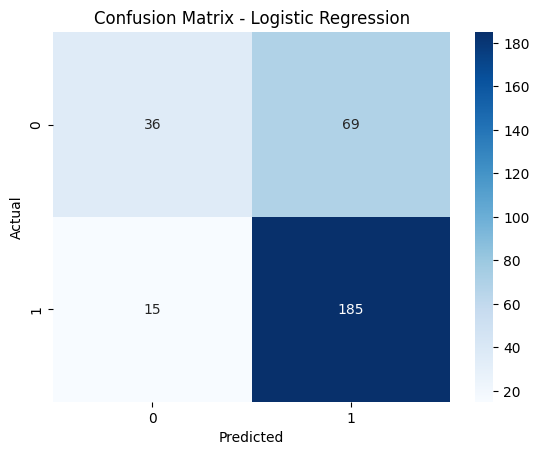


===== Random Forest =====
Accuracy: 0.9114754098360656
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.78      0.86       105
           1       0.89      0.98      0.94       200

    accuracy                           0.91       305
   macro avg       0.92      0.88      0.90       305
weighted avg       0.92      0.91      0.91       305



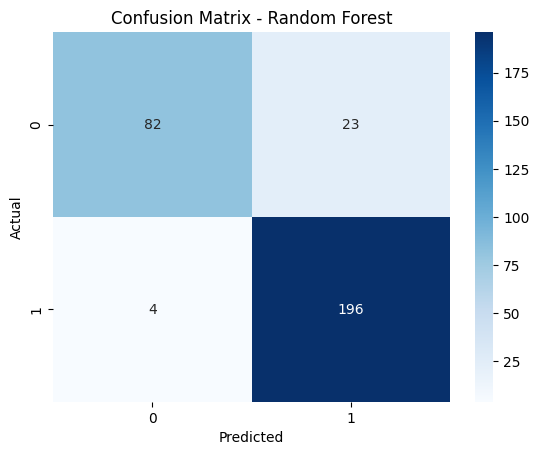

Feature Importance:
                    Feature  Importance
0                      Age    0.179478
5                 Nap_Hour    0.159260
3           Weekends_Sleep    0.125879
4        Sleep_Consistency    0.125450
9  Negativity_Sleep_Habits    0.105883
8          Skipped_Classes    0.075676
2               Department    0.072923
1                   Gender    0.071225
6       Noise_Effect_Sleep    0.060840
7                  Devices    0.023387

===== Gradient Boosting =====
Accuracy: 0.8229508196721311
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.54      0.68       105
           1       0.80      0.97      0.88       200

    accuracy                           0.82       305
   macro avg       0.85      0.76      0.78       305
weighted avg       0.84      0.82      0.81       305



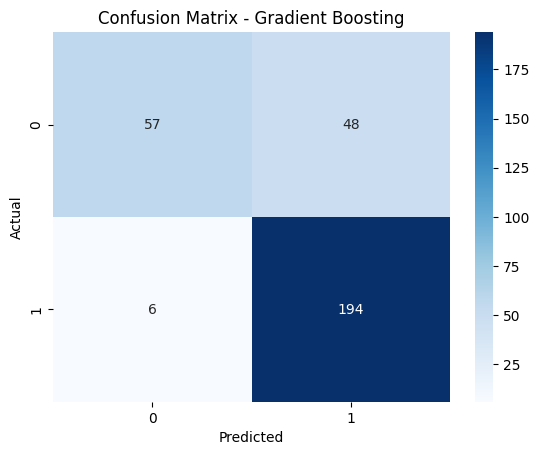

Feature Importance:
                    Feature  Importance
4        Sleep_Consistency    0.271037
5                 Nap_Hour    0.137662
0                      Age    0.125003
3           Weekends_Sleep    0.122380
9  Negativity_Sleep_Habits    0.106018
8          Skipped_Classes    0.085360
2               Department    0.053297
1                   Gender    0.050495
7                  Devices    0.024706
6       Noise_Effect_Sleep    0.024042

===== XGBoost =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:01:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8786885245901639
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.70      0.80       105
           1       0.86      0.97      0.91       200

    accuracy                           0.88       305
   macro avg       0.89      0.84      0.86       305
weighted avg       0.88      0.88      0.87       305



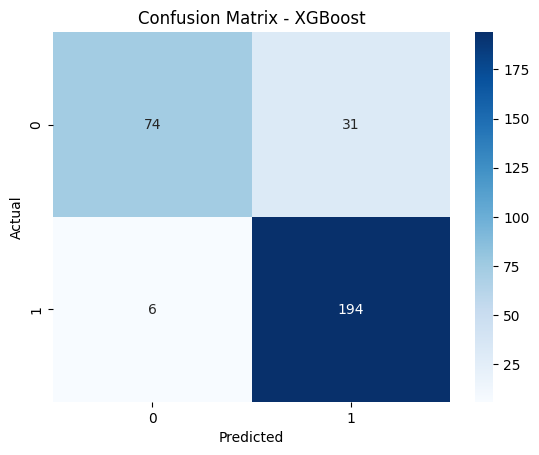

Feature Importance:
                    Feature  Importance
4        Sleep_Consistency    0.325639
8          Skipped_Classes    0.093428
3           Weekends_Sleep    0.080032
2               Department    0.078968
9  Negativity_Sleep_Habits    0.077808
1                   Gender    0.077722
5                 Nap_Hour    0.071380
6       Noise_Effect_Sleep    0.067373
0                      Age    0.066641
7                  Devices    0.061008

===== CatBoost =====
Accuracy: 0.9639344262295082
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.95       105
           1       0.96      0.99      0.97       200

    accuracy                           0.96       305
   macro avg       0.97      0.95      0.96       305
weighted avg       0.96      0.96      0.96       305



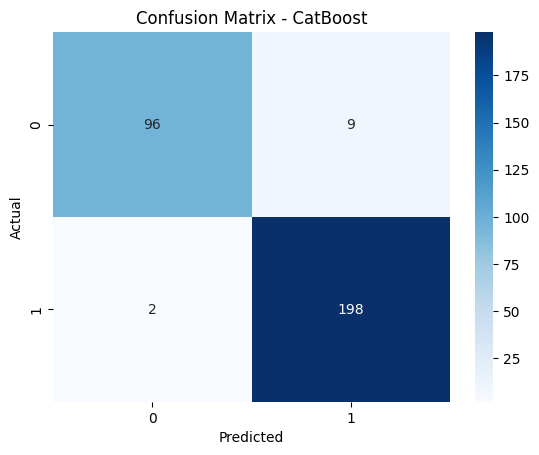

Feature Importance:
                    Feature  Importance
0                      Age   15.009183
5                 Nap_Hour   14.704434
3           Weekends_Sleep   14.107936
9  Negativity_Sleep_Habits   13.237987
1                   Gender   11.217828
4        Sleep_Consistency    9.884838
8          Skipped_Classes    8.493057
6       Noise_Effect_Sleep    7.728711
2               Department    4.940491
7                  Devices    0.675536


In [ ]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})

    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Feature importance for tree-based models
    if name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost']:
        importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        print("Feature Importance:\n", importance)

In [ ]:
# Step 6: Summary of all models
results_df = pd.DataFrame(results)

# Remove duplicate models (keep the first occurrence)
results_df = results_df.drop_duplicates(subset=['Model']).sort_values(by='Accuracy', ascending=False)

print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

# Highlight the best model
best_model = results_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']} (Accuracy = {best_model['Accuracy']:.4f})")


=== Model Comparison ===
              Model  Accuracy
           CatBoost  0.963934
      Random Forest  0.911475
            XGBoost  0.878689
  Gradient Boosting  0.822951
Logistic Regression  0.724590

🏆 Best Model: CatBoost (Accuracy = 0.9639)


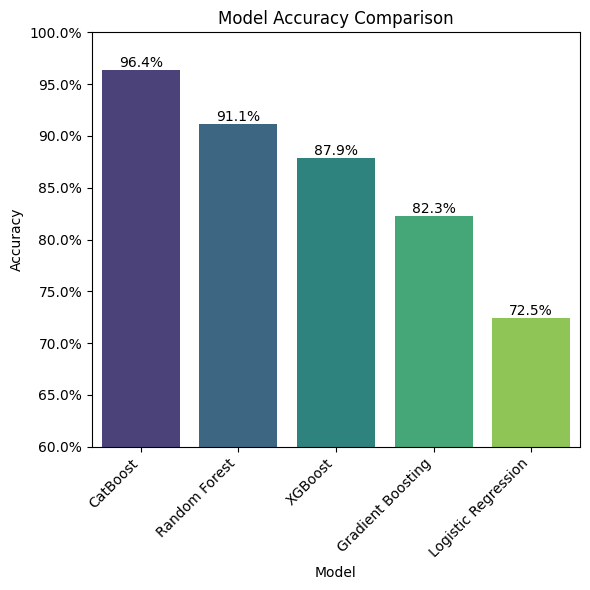

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0) # Set y-limit to 0.6 to 1.0

# Format y-axis labels as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='{:.1%}')

plt.show()